In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib agg

import sys
ipython = get_ipython()

def hide_traceback(exc_tuple=None, filename=None, tb_offset=None,
                   exception_only=False, running_compiled_code=False):
    etype, value, tb = sys.exc_info()
    return ipython._showtraceback(etype, value, ipython.InteractiveTB.get_exception_only(etype, value))

ipython.showtraceback = hide_traceback
    
print("Magic Loaded")

Magic Loaded


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/home/lszucchi/Jupyter')
sys.path.append('/home/lszucchi/Jupyter/HPIB')
       
from HPIB.HP4155 import HP4155
from HPIB.HPT import Plot, PlotVgs, PlotVp, CalcIsSat, SecDer, Plot2P, PlotDiode4P,WriteLog
from HPIB.DevParams import UMC
from HPIB.INOSerial import Arduino

from BFmodule import DR

from YFunc import YFuncExtraction
#from Test import TestDevice, WriteLog

from IPython.display import clear_output, display
from os import makedirs, rename
from os.path import isfile

In [3]:
from time import sleep
from datetime import datetime, timedelta

Elsa=DR()

HP=HP4155("GPIB0::17", debug=False)

SM=Arduino('/dev/ttyUSB0')
print(SM.ask('*'.encode()))

clear_output()
raise UserWarning("Comms opened")

Elsa v2.4.2 at 143.106.18.130
HEWLETT-PACKARD,4155A,0,01.04:01.04:01.00
b'*'



UserWarning: Comms opened

In [4]:
HP.IntTime = "LONG"

In [ ]:
HP.SetVgs(0, 1, 0.1)

In [5]:
HP.Diode4P(-0.5, 1, 0.025, Im='SMU1', Ip='SMU2', Vm='SMU3', Vp='SMU4', Comp=2e-3)

Diode=(-0.5, 1, 0.025)


0

In [36]:
print(f"Measuring {HP.term} ", end='')
HP.measure() 
Poll=HP.PollDR(1, 1, 5)
if not Poll: df=HP.get_realdata()
else: print("Timeout")

Done Diode4P. Duration: 0:00:39                                       


In [ ]:
HP.stop()

In [ ]:
df

In [58]:
path = '~/Jupyter/Medidas/Diodo'
makedirs(path, exist_ok=True)
path =  f"{path}/{HP.term}-{datetime.now().strftime('%y%m%d %H%M%S')}.csv"

df.to_csv(path, float_format='%+.6E')

V=df["Vf"]["None"].to_numpy()
I=df["If"]["None"].to_numpy()

OSError: Cannot save file into a non-existent directory: '/home/lszucchi/Jupyter/Medidas/Diodo'

In [ ]:
print(f"I0={-np.average(I[V<-0.1])}")

In [34]:
SM.opench(3)

'Open INO: ch 3'

~/Medidas/Diode4P-250925 135348


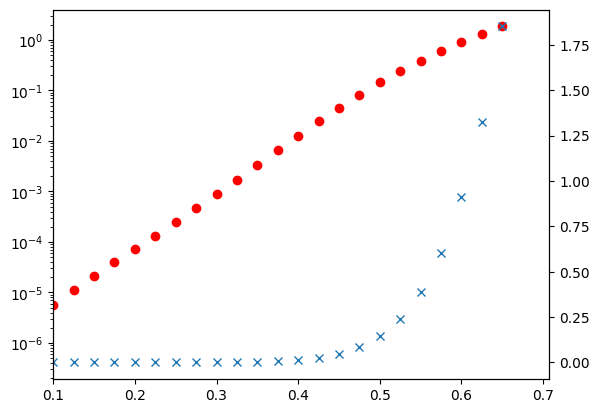

In [52]:
%matplotlib inline

plt.rcParams['font.family'] = 'DejaVu Sans'

fig , ax = plt.subplots()
ax.plot(V, I*1e3, 'or')

###################################################
# ext e escala mais fãcil
path =  path.replace('.csv', '')
print(path)
ax.set_yscale('log')

ax2=plt.twinx(ax)
ax2.plot(V, I*1e3, 'x')

ax.set_xlim((0.1, None))

fig.savefig(path, format='png')


#suposição que v>3*vt (300k) artigo do zuchi 

In [ ]:
#gmodel lmfit - no linnear the model class - independent vars pra definir a temperatura como constante 
#usar lmfit pra tirar minimos quadrados extrair rs n e io 
#ver modelo do zuchi 
#xi model 

[1.04269778e+00 6.81077678e-10 1.00000000e-10 2.95000000e+02]
[1.44099785e+00 5.98939951e-10 6.93185547e+01 2.95503247e+02]
[1.56476441e+00 5.66609460e-10 3.08573929e+01 2.95659624e+02]
[1.55391711e+00 4.94957183e-10 2.91156103e+01 2.95645919e+02]
[1.55126804e+00 4.62282667e-10 2.97042604e+01 2.94232011e+02]
[1.55117799e+00 4.62170367e-10 2.97424929e+01 2.94183953e+02]
[1.55117712e+00 4.62160759e-10 2.97428956e+01 2.94183486e+02]
[1.55117712e+00 4.62160759e-10 2.97428956e+01 2.94183486e+02]
Both `ftol` and `xtol` termination conditions are satisfied.
Function evaluations 8, initial cost 7.0114e-02, final cost 1.2058e-05, first-order optimality 7.39e-09.
[1.55117712e+00 4.62160759e-10 2.97428956e+01 2.94183486e+02]


/tmp/ipykernel_2515/2158800958.py:7: RuntimeWarning: invalid value encountered in log
  return n*Ut*np.log(If/I0)+Rs*If


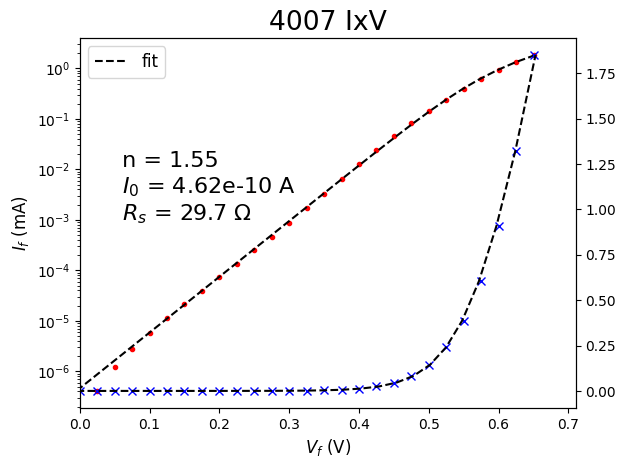

In [54]:
from scipy.optimize import least_squares
from scipy.constants import k, e

def Vf(If, x):
    n, I0, Rs, T=x
    Ut=k*T/e
    return n*Ut*np.log(If/I0)+Rs*If

def CostVf(x, I, V, weight):
    print(x)
    return weight*(Vf(I, x)-V)

def jac(x, I, V, weight):
    n, I0, Rs, T=x
    Ut=k*T/e
    jac_x0=Ut*np.log(I/I0)
    jac_x1=[-n*Ut/I0 for x in I]
    jac_x2=I
    jac_x3=n*k*np.log(I/I0)/e
    return np.transpose(weight*[jac_x0, jac_x1, jac_x2, jac_x3])

V_fit = V[np.where(I>1e-8)]
I_fit = I[np.where(I>1e-8)]

p=np.polyfit(np.log(I_fit), V_fit, 1)

x0 = [np.exp(p[0]), np.exp(-p[1]/p[0]), 0, 295]

x0_bounds = (1,5)
x1_bounds = (0, 1)
x2_bounds = (0, np.inf)  # +/- np.inf can be used instead of None
x3_bounds = (0, 300)
bounds = np.transpose([x0_bounds, x1_bounds, x2_bounds, x3_bounds])

# Fit model to data
res = least_squares(CostVf, x0, jac=jac, bounds=bounds, kwargs={"I":I_fit, "V": V_fit, "weight":V_fit}, verbose=1, ftol=1e-12, gtol=1e-15)

print(res.x)
n, I0, Rs, T= res.x

fig , ax = plt.subplots()
ax.plot(V, I*1e3, '.r')

ax2=plt.twinx(ax)
ax2.plot(V, I*1e3, 'xb')
ax.set_yscale('log')

ax.plot(Vf(I, res.x), I*1e3,"k--",label = "fit")
ax2.plot(Vf(I, res.x), I*1e3,"k--")
ax.set_xlim((0,None))
ax.legend()

ax.set_ylabel("$I_f$ (mA)")
ax.set_xlabel("$V_f$ (V)")

ax.set_title("4007 IxV")
ax.text(0.05,1e-3, " n = %.2f\n $I_0$ = %.2e A\n $R_s$ = %.1f $\mathrm{\Omega}$" %(n,I0,Rs))

fig.savefig(path.replace('.csv', '.png'))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k, e
from lmfit import Model, Parameters, create_params

V_fit = V[np.where(I>1e-6)]
I_fit = I[np.where(I>1e-6)]

p=np.polyfit(np.log(I_fit), V_fit, 1)

I0=np.exp(-p[1]/p[0])
n=np.exp(p[0])
print(I0, n)

def Vf(If, n, I0, Rs, T):
    Ut=k*T/e
    return n*Ut*np.log(If/I0)+Rs*If

gmodel = Model(Vf)
pars_bounded = create_params(n=dict(value=n, min=1),
                             I0=dict(value=I0, min=1e-15),
                            Rs=dict(value=1, vary=False),
                            T=dict(value=295, vary=False))
res=gmodel.fit(V_fit, pars_bounded, If=I_fit, weights=V_fit)
print(res.fit_report())
p=[res.params['n'].value, res.params['I0'].value, res.params['Rs'].value]

plt.plot(V_fit, I_fit, 'x')
plt.plot(Vf(I_fit, p[0], p[1], p[2], 295), I_fit)
plt.show()



In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(V, I, 'bo')
plt.ylabel('corrente')
plt.xlabel('Tensao')
plt.title('Original GDP Data')
plt.show()

In [ ]:
from scipy.optimize import least_squares

def Vf(If, x, T):
    n, I0, Rs=x
    Ut=k*T/e
    return n*Ut*np.log(If/I0)+Rs*If

#calcula o erro, v dos parametros e o v da entrada
def CostVf(x, I, V, T, weight):
    print(x)
    return weight*(Vf(I, x, T)-V)

#derivada do vf x por cada parametro
def jac(x, I, V, T, weight):
    n, I0, Rs=x
    Ut=k*T/e
    jac_x0=Ut*np.log(I/I0)
    jac_x1=[-n*Ut/I0 for x in I]
    jac_x2=I
    return np.transpose(weight*[jac_x0, jac_x1, jac_x2])

V_fit = V[np.where(I>1e-7)]
I_fit = I[np.where(I>1e-7)]

p=np.polyfit(np.log(I_fit), V_fit, 1)

x0 = [np.exp(p[0]), np.exp(-p[1]/p[0]), 0]

x0_bounds = (1,5)
x1_bounds = (0, 1)
x2_bounds = (0, np.inf)  # +/- np.inf can be used instead of None
bounds = np.transpose([x0_bounds, x1_bounds, x2_bounds])

# Fit model to data
res = least_squares(CostVf, x0, jac=jac, bounds=bounds, kwargs={"I":I_fit, "V": V_fit, "T":295, "weight":V_fit}, verbose=1, ftol=1e-12, gtol=1e-15)

print(res.x)
n, I0, Rs= res.x

plt.plot(V_fit, I_fit, 'x')
plt.plot(Vf(I_fit, res.x, 295), I_fit)
plt.show()

# 

# 